In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/COVID_US_cases.csv', parse_dates=['date'])

# Keep only rows with valid positive case counts
df = df[df['new_confirmed'] >= 0].copy()

# Restrict to Jan 2020 – Sep 2022 (last clean data)
df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2022-09-15')].copy()

# Derive year, ISO week number, and month
df['year'] = df['date'].dt.year
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['month'] = df['date'].dt.month

# Aggregate to weekly totals
weekly = (
    df.groupby(['year', 'week'])
    .agg(cases=('new_confirmed', 'sum'), date=('date', 'min'))
    .reset_index()
)

weekly.head(10)

,year,week,cases,date
0,2020,3,1,2020-01-13
1,2020,4,9,2020-01-20
2,2020,5,5,2020-01-27
3,2020,6,7,2020-02-03
4,2020,7,6,2020-02-10
5,2020,8,16,2020-02-17
6,2020,9,74,2020-02-24
7,2020,10,716,2020-03-02
8,2020,11,4988,2020-03-09
9,2020,12,34099,2020-03-16


In [3]:
# Build a (year x week) pivot so each column is a week-of-year (1–53)
# and each row is a year
pivot = weekly.pivot(index='year', columns='week', values='cases')

# Fill missing weeks (e.g. week 53 in some years) with 0
all_weeks = range(1, 54)
pivot = pivot.reindex(columns=all_weeks, fill_value=np.nan)

# Clip 2022 to only the weeks we have data for
last_2022_week = weekly[weekly['year'] == 2022]['week'].max()
pivot.loc[2022, last_2022_week + 1:] = np.nan

print(pivot.shape)
pivot

(3, 53)


week,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
year,,,,,,,,,,,,,,,,,,,,,
2020,NaN,NaN,1.0,9.0,5.0,7.0,6.0,16.0,74.0,716.0,...,636056.0,803264.0,1050512.0,1203780.0,1127257.0,1383427.0,1488601.0,1507244.0,1274666.0,820170.0
2021,1714127.0,1515267.0,1185176.0,1026227.0,820731.0,632066.0,450854.0,470888.0,405346.0,422015.0,...,515022.0,587572.0,655522.0,502616.0,849875.0,837105.0,932649.0,1439094.0,2438729.0,671431.0
2022,5036233.0,5648074.0,4849622.0,3656770.0,2089957.0,1209394.0,748061.0,456386.0,333722.0,244471.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,448828.0,NaN


In [4]:
# Month label positions: approximate week number for the 1st of each month
# (using 2021 as representative year)
month_starts = (
    df[df['year'] == 2021]
    .groupby('month')
    .agg(first_week=('week', 'min'))
    .reset_index()
)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_starts['name'] = month_names
month_starts

,month,first_week,name
0,1,1,Jan
1,2,5,Feb
2,3,9,Mar
3,4,13,Apr
4,5,17,May
5,6,22,Jun
6,7,26,Jul
7,8,30,Aug
8,9,35,Sep
9,10,39,Oct


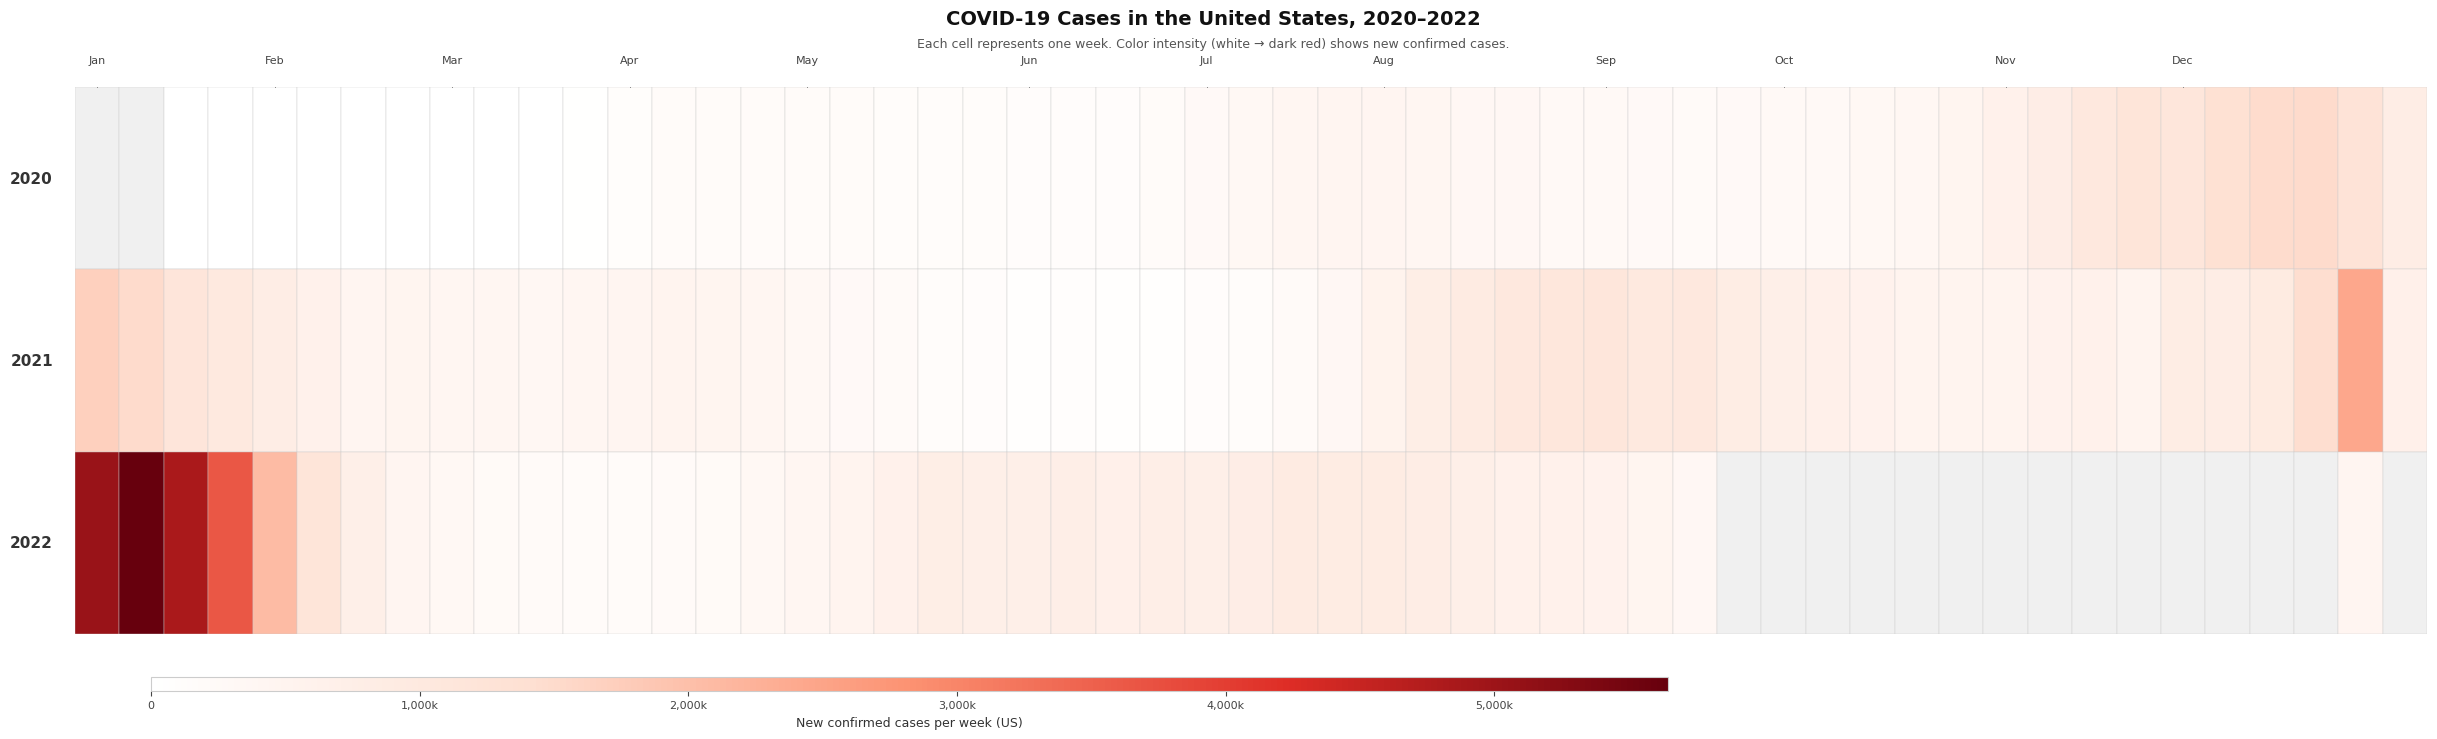

Saved to assets/final.png


In [5]:
# --- Plot ---
years = sorted(pivot.index.tolist())   # [2020, 2021, 2022]
n_years = len(years)
n_weeks = 53

cell_w = 0.55   # width of each cell (inches)
cell_h = 1.6    # height of each row (inches)
left_margin = 0.7
right_margin = 0.5
top_margin = 1.4
bottom_margin = 0.9

fig_w = left_margin + n_weeks * cell_w + right_margin
fig_h = top_margin + n_years * cell_h + bottom_margin

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, n_weeks)
ax.set_ylim(0, n_years)
ax.axis('off')

# Color map: white → deep red
cmap = mcolors.LinearSegmentedColormap.from_list(
    'white_red', ['#ffffff', '#fee0d2', '#fc9272', '#de2d26', '#67000d']
)

max_cases = weekly['cases'].max()

for row_i, year in enumerate(years):
    y_pos = n_years - 1 - row_i   # top year at top
    for week in range(1, n_weeks + 1):
        cases = pivot.loc[year, week]
        if pd.isna(cases):
            color = '#f0f0f0'
            alpha = 1
        else:
            norm_val = cases / max_cases
            color = cmap(norm_val)
            alpha = 1
        rect = Rectangle(
            (week - 1, y_pos), 1, 1,
            facecolor=color, edgecolor='#cccccc', linewidth=0.3
        )
        ax.add_patch(rect)

# Year labels on left
for row_i, year in enumerate(years):
    y_pos = n_years - 1 - row_i + 0.5
    ax.text(-0.5, y_pos, str(year), va='center', ha='right',
            fontsize=11, fontweight='bold', color='#333333')

# Month labels on top (using week positions)
for _, mrow in month_starts.iterrows():
    wx = mrow['first_week'] - 1   # 0-indexed x
    ax.text(wx + 0.5, n_years + 0.12, mrow['name'],
            va='bottom', ha='center', fontsize=8, color='#444444')
    # Tick line
    ax.plot([wx + 0.5, wx + 0.5], [n_years, n_years + 0.08],
            color='#888888', linewidth=0.7)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=mcolors.Normalize(vmin=0, vmax=max_cases))
sm.set_array([])
cbar_ax = fig.add_axes([0.15, 0.03, 0.5, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('New confirmed cases per week (US)', fontsize=9, color='#333333')
cbar.ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000):,}k' if x >= 1000 else str(int(x)))
)
cbar.ax.tick_params(labelsize=8, colors='#444444')
cbar.outline.set_edgecolor('#cccccc')

# Title and subtitle
fig.text(0.5, 0.99, 'COVID-19 Cases in the United States, 2020–2022',
         ha='center', va='top', fontsize=14, fontweight='bold', color='#111111')
fig.text(0.5, 0.95, 'Each cell represents one week. Color intensity (white → dark red) shows new confirmed cases.',
         ha='center', va='top', fontsize=9, color='#555555')

plt.savefig('assets/final.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved to assets/final.png')